<a href="https://colab.research.google.com/github/OAKVISUALZ/Pytorch/blob/main/02_pytorch_classification_with_pytorch_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Neural Network classification with PyTorch
Classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options).

Book version of this notebook -

All other resources

Ask a question

## 1. Make classifcation data and get it ready

In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles

# Make 1000 samples

n_samples = 1000

# Create circles

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X\n: {X[:5]}")
print(f"First 5 samples of y\n  {y[:5]}")

First 5 samples of X
: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y
  [1 1 1 1 0]


In [ ]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [ ]:
# Make DataFrame of circle

import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


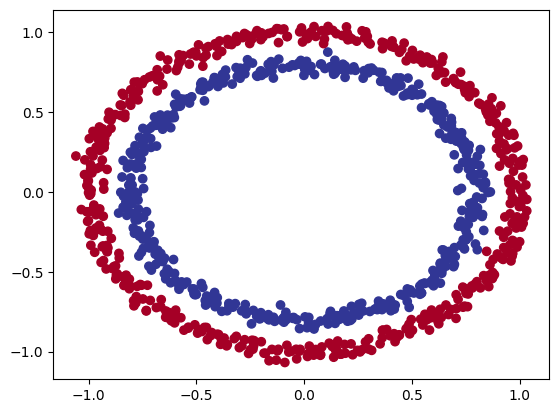

In [ ]:
# Visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

Note: The data we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1 Check input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
#view the first example of features and labels
X_sample = X[0]
y_sample = y[0]

1.2 Turn data into tensors and create train and test splits

In [ ]:
import  torch
torch.__version__

'2.11.0+cpu'

In [ ]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [ ]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [ ]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, #0.2 = 20% of data will be the train
                                                    random_state=42)

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [ ]:
n_samples

1000

## 2. Building a model

Let's build a model toclassify our blue and red dots

To do so, we want to:
1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model(by subclassing 'nn.Module')
3. Define a loss function and optimizer
4. Create a training and test loop


In [ ]:
# Import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
X_train.shape

torch.Size([800, 2])

Now we've setup device agnostic code, let's create a model that:

1. Subclasses 'nn.Module' (almost all models in PyTorch subclass 'nn.Module')
2. Create 2 'nn.Linear()' layers that are capable of handling the shapes of our data
3. Defines a 'forward()' method that outlines the forward pass (or forward computation)
4. Instatiate an instance of our model class and send it to the target device


In [ ]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
      super().__init__()
      # 2. Create 2 nn.Linear layers capable of handing the
      self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features
      self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features from previouse layer and outputs a single feature (same shape as y)



    #3. Define a forward() method that outlines the forward pass
    def forward(self, x):
      return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
device

'cpu'

In [ ]:
next(model_0.parameters()).device

device(type='cpu')

In [ ]:
# Let's replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0966, -0.4322],
                      [ 0.5591,  0.6340],
                      [-0.4869,  0.5375],
                      [-0.4910, -0.4275],
                      [-0.6527,  0.0273]])),
             ('0.bias', tensor([-0.1764,  0.1499, -0.3971, -0.0141, -0.2475])),
             ('1.weight',
              tensor([[ 0.0444,  0.0274,  0.2627, -0.4042,  0.1059]])),
             ('1.bias', tensor([0.2261]))])

In [ ]:
# Make predictions
with torch.inference_mode():
 untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions: {untrained_preds[:10]}")
print(f"\nFirst 10 labes:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions: tensor([[ 0.3047],
        [ 0.4002],
        [-0.0164],
        [ 0.3959],
        [-0.1284],
        [-0.0692],
        [ 0.2887],
        [ 0.1785],
        [-0.0112],
        [ 0.4054]])

First 10 labes:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

Which loss fuction or optimizer should you use

Again... this is problem specific

For example for regression you might want MAE or MSE (mean absolute erorr or mean square error)

For classification you might want to binary cross entropy or categorical cross entropy (cross entropy)

As a reminder, the loss function measures how *wrong* your models predictions are

And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has may built-in options.

* For some common choices of loss functions and optimizers -

* For the loss function we're going to use 'torch.nnBCEWithLogitloss' for more on what binary cross entropy (BCE) is, check this article ...

* For different optimizers see 'torch.optim'


In [ ]:
# Setup the loss function
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitsLoss = sigmoid activation function

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [ ]:
# Calculate accuracy- out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

## 3. Train model

To train model, we're going  to need to build a training loop:

1. forward pass
2. calculate the loss
3. optimizer zero grad
4. Loss backward(backpropagation)
5. Optimizer step (gradient descent)

## 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g sigmoid for binary classification and softmax for multiclass classification)

Then we can convert our model's prediction probabilities to prediction labels by either rounding them or taking the

In [ ]:
# view the first 5 outputs of the forward pass on the test dat
model_0.eval()
with torch.inference_mode():
 y_logits = model_0(X_test.to(device)) [:5]
y_logits



tensor([[ 0.3047],
        [ 0.4002],
        [-0.0164],
        [ 0.3959],
        [-0.1284]])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilites
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5756],
        [0.5987],
        [0.4959],
        [0.5977],
        [0.4679]])

For our prediction probability values, we need to perform a range-style rounding on them:

* y_pred_probs >= 0.5, 'y=1' (class 1)

* y_pred_probs <0.5, y=0 (class 0)


In [ ]:
#torch.round(y_pred_probs)

#find the predicted labels

y_preds = torch.round(y_pred_probs)

# In full ( logits -> pred probs -> pred probs)

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device)) [:5] ))

# check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 0., 1., 0.])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### 3.2 Building a training and test loop

In [ ]:
torch.manual_seed(42)
#torch.cuda.manual_seed(42)

# set the number of epochs
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
  ### training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

  # 2. Calculate loss/accuracy
  # nn.BCEWithLogitsLoss expects raw logits as input
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  # print out what's happenin'
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69754, Acc 52.12% | Test loss: 0.70655, Test acc 49.00%
Epoch: 10 | Loss: 0.69625, Acc 51.88% | Test loss: 0.70410, Test acc 49.00%
Epoch: 20 | Loss: 0.69542, Acc 51.50% | Test loss: 0.70235, Test acc 50.00%
Epoch: 30 | Loss: 0.69485, Acc 51.62% | Test loss: 0.70104, Test acc 50.00%
Epoch: 40 | Loss: 0.69443, Acc 51.12% | Test loss: 0.70001, Test acc 49.00%
Epoch: 50 | Loss: 0.69413, Acc 51.00% | Test loss: 0.69919, Test acc 48.00%
Epoch: 60 | Loss: 0.69389, Acc 51.00% | Test loss: 0.69853, Test acc 48.00%
Epoch: 70 | Loss: 0.69371, Acc 51.12% | Test loss: 0.69798, Test acc 47.00%
Epoch: 80 | Loss: 0.69356, Acc 51.00% | Test loss: 0.69752, Test acc 47.00%
Epoch: 90 | Loss: 0.69345, Acc 51.25% | Test loss: 0.69714, Test acc 47.00%
Epoch: 100 | Loss: 0.69336, Acc 51.38% | Test loss: 0.69681, Test acc 47.00%
Epoch: 110 | Loss: 0.69329, Acc 51.25% | Test loss: 0.69654, Test acc 47.00%
Epoch: 120 | Loss: 0.69323, Acc 51.38% | Test loss: 0.69630, Test acc 47.00%
Epoch: 130

In [ ]:
loss_fn

BCEWithLogitsLoss()

## 4. Make predictions and evaluate the model

From the metrics it looks like the model isn't learning anything...

So to inspect it let's make some predictions and make them visual:

In other words, "Visualize, visualize, visualize"

Tod od so, we're going to import a function called 'plot_decision_boundary()'


In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Download the helper_functions.py file")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


Download the helper_functions.py file


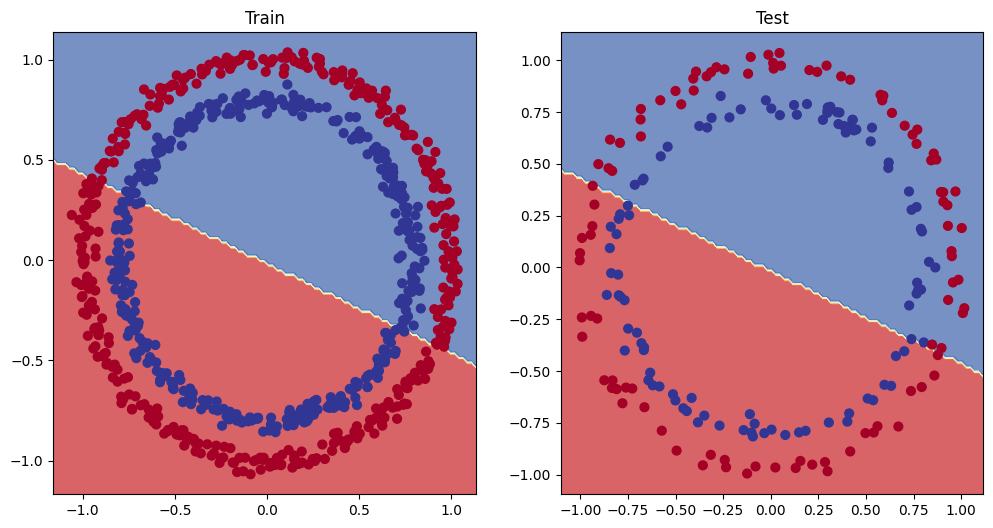

In [ ]:
from helper_functions import plot_decision_boundary

# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model(from a model perspective)

* Add more layers - give the model morechances to learn about patterns in the data

* Add more hidden units - go from 5 hidden units to 10 hidden units

* Fit for  longer

* Changing the activation functions

* Change the learning rate

* Change the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data.

And because these options are all balues we (as machine learning engineers and data scientists) can change, they are referred as **hyperparameters**

Let's try and improve our model by:

* Addinf more hidden units; 5 -> 10
* Increase the number of layers: 2-> 3
* Increase the number of epochs: 100 -> 1000

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1054, -0.4571],
                      [ 0.5548,  0.6436],
                      [-0.4735,  0.4878],
                      [-0.5158, -0.3416],
                      [-0.6459,  0.0034]])),
             ('0.bias', tensor([-0.1846,  0.1522, -0.4176,  0.0198, -0.2570])),
             ('1.weight',
              tensor([[ 0.1702, -0.0956,  0.1478, -0.3499,  0.0805]])),
             ('1.bias', tensor([0.1362]))])

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
   # z = self.layer_1(x)
   # z = self.layer_2(z)
   # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing operations leverage speed ups where possible behind the
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [ ]:
# write a training and evaluation loop for the model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_1.train()

  # 1. Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate loss and accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step (gradient descent)
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss and accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 100 | Loss: 0.69305, Acc: 50.38% | Test Loss: 0.69379, Test Acc: 48.00%
Epoch: 200 | Loss: 0.69299, Acc: 51.12% | Test Loss: 0.69437, Test Acc: 46.00%
Epoch: 300 | Loss: 0.69298, Acc: 51.62% | Test Loss: 0.69458, Test Acc: 45.00%
Epoch: 400 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69465, Test Acc: 46.00%
Epoch: 500 | Loss: 0.69298, Acc: 51.00% | Test Loss: 0.69467, Test Acc: 46.00%
Epoch: 600 | Loss: 0.69298, Acc: 51.00% | Test Loss: 0.69468, Test Acc: 46.00%
Epoch: 700 | Loss: 0.69298, Acc: 51.00% | Test Loss: 0.69468, Test Acc: 46.00%
Epoch: 800 | Loss: 0.69298, Acc: 51.00% | Test Loss: 0.69468, Test Acc: 46.00%
Epoch: 900 | Loss: 0.69298, Acc: 51.00% | Test Loss: 0.69468, Test Acc: 46.00%


Text(0.5, 1.0, 'Test')

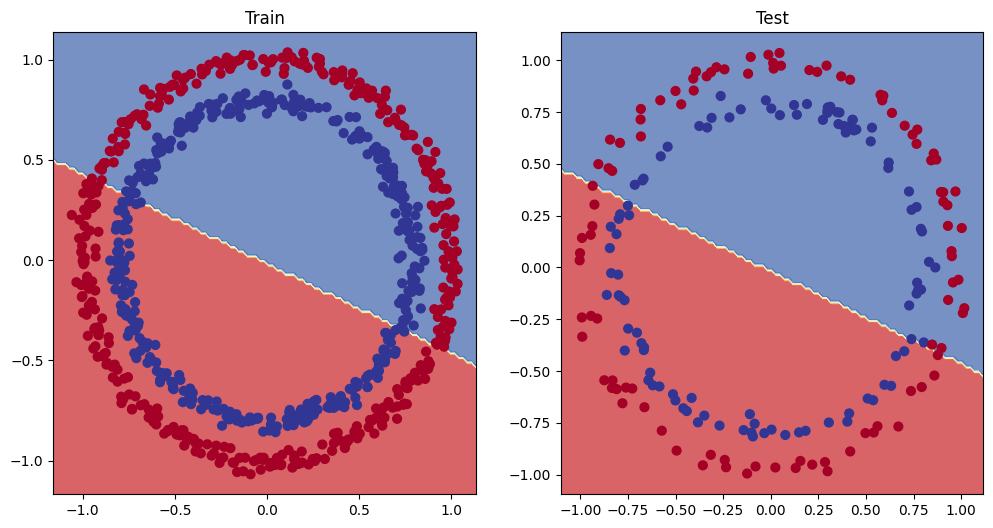

In [ ]:
# Plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plot_decision_boundary(model_1, X_test, y_test)
plt.title("Test")



### 5.2 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a larger problem is to test out a smaller problem

In [ ]:
# create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regrssion = weight * X_regression + bias



In [ ]:
# Map typo from previous cell to correct spelling
y_regression = y_regrssion

# Create train and test splits
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

#Check the lengths of each
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

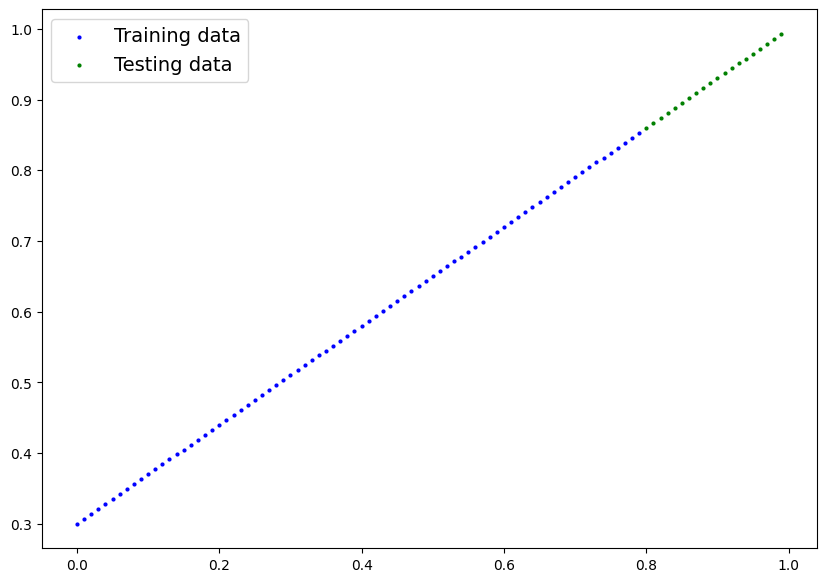

In [ ]:
def plot_predictions(train_data=X_train_regression,
                     train_labels=y_train_regression,
                     test_data=X_test_regression,
                     test_labels=y_test_regression,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data.cpu(), train_labels.cpu(), c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data.cpu(), test_labels.cpu(), c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data.cpu(), predictions.cpu(), c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})

plot_predictions()

In [ ]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

### 5.2 Adjusting 'model_1' to fit a straight line

In [ ]:
# Same architecture as model_1 (but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)

).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_2. parameters(),
                            lr=0.01)

In [ ]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device (Corrected the typo: y_train_regressin -> y_train_regression)
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  # Print out what's happenin

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test loss: 0.00360


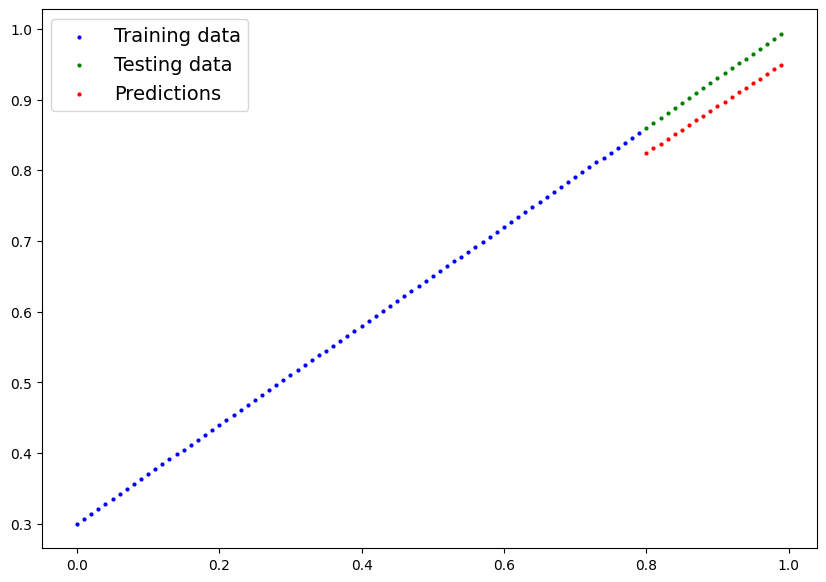

In [ ]:
# Turn on evaluation mode

model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

# Plot data and predictions
plot_predictions(train_data=X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression,
                 predictions = y_preds)

## 6. The missing piece: non-linearity

"What patterns could you draw if you were give an infinite amount of a straight and non-straight lines?"

Or in machine learning terms, an infinite(but really it is finite) or linear and non-linear functions?

### 6.1 Recreating non-linear data (red and blue circles)

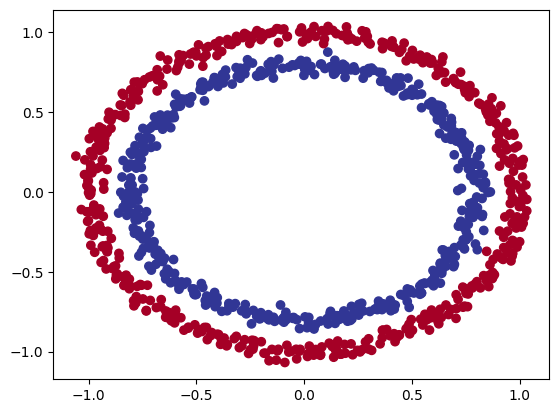

In [ ]:
# Make and plot data

import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);



In [ ]:
# Convert data to tensors and then to train and test splits

import torch
from sklearn.model_selection import train_test_split

# Convert to PyTorch tensors only if they are not already tensors
if not isinstance(X, torch.Tensor):
    X = torch.from_numpy(X).type(torch.float)
if not isinstance(y, torch.Tensor):
    y = torch.from_numpy(y).type(torch.float)

# split into train and test sets (fixing the typo: test_train_split -> train_test_split)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity

* Linear = straight linear

* Non-linear = non-straight lines

Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear) functions which are potentially are able to find patterns data


In [ ]:
# Build a model with non linear activation functions
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU() # Corrected casing from ReLu to ReLU


  def forward(self, x):
    # Chain the layers and place non-linear activation functions in between
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# Setup loss and optimizer

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.1)

### 6.3 Training our model with non-linearity

In [ ]:
# random seeds
torch.manual_seed(42) # Corrected from manual() to manual_seed()
torch.cuda.manual_seed(42)

# Put all data target device

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


# Loop through data
epochs = 1000

for epoch in range(epochs):
  ### Training
  model_3.train()

  #  1. Forward pass (corrected to use X_train instead of X_test)
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> prediction probabilities -> prediction labels

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train) #BCEWithLogitsLoss (takes in logits as first input)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  # print out what's happenin' (indented correctly inside the loop)
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f} % | Test Loss: {test_loss: .4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6929, Acc: 50.00 % | Test Loss:  0.6932, Test Acc: 50.00%
Epoch: 100 | Loss: 0.6912, Acc: 52.88 % | Test Loss:  0.6910, Test Acc: 52.50%
Epoch: 200 | Loss: 0.6898, Acc: 53.37 % | Test Loss:  0.6894, Test Acc: 55.00%
Epoch: 300 | Loss: 0.6879, Acc: 53.00 % | Test Loss:  0.6872, Test Acc: 56.00%
Epoch: 400 | Loss: 0.6852, Acc: 52.75 % | Test Loss:  0.6841, Test Acc: 56.50%
Epoch: 500 | Loss: 0.6810, Acc: 52.75 % | Test Loss:  0.6794, Test Acc: 56.50%
Epoch: 600 | Loss: 0.6751, Acc: 54.50 % | Test Loss:  0.6729, Test Acc: 56.00%
Epoch: 700 | Loss: 0.6666, Acc: 58.38 % | Test Loss:  0.6632, Test Acc: 59.00%
Epoch: 800 | Loss: 0.6516, Acc: 64.00 % | Test Loss:  0.6476, Test Acc: 67.50%
Epoch: 900 | Loss: 0.6236, Acc: 74.00 % | Test Loss:  0.6215, Test Acc: 79.00%


### 6.4 Evaluating a model trained with non-linear activation functions

In [ ]:
# Makes predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

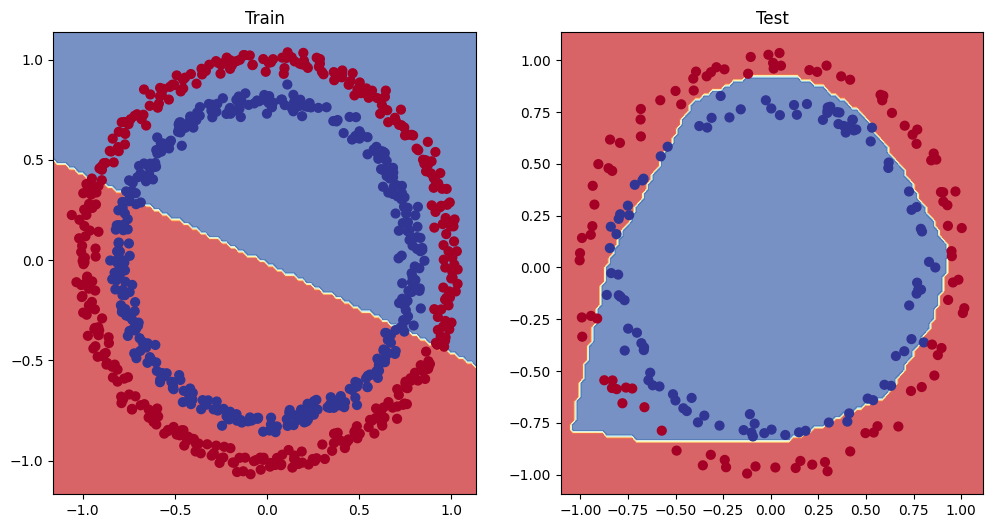

In [ ]:
# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model-1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3  = has non-linearity

## 7. Replicating non-linear activation functions
Remember, rather than tell the model what to learn, we give it the tools to discover patterns in data and it tries to figure patterns on its own.

And these tools are linear & non-lienear functions

In [ ]:
# create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A.dtype

torch.float32

In [ ]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

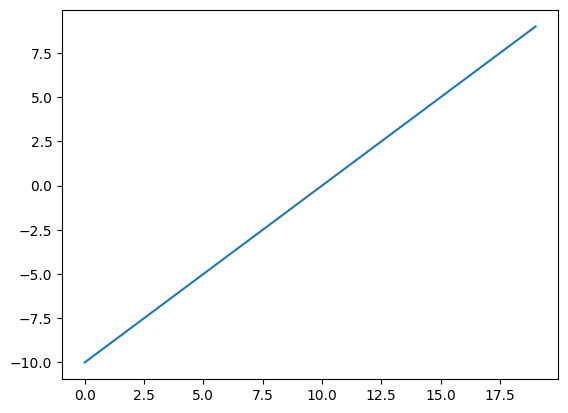

In [ ]:
# Visualize the tensor
plt.plot(A);

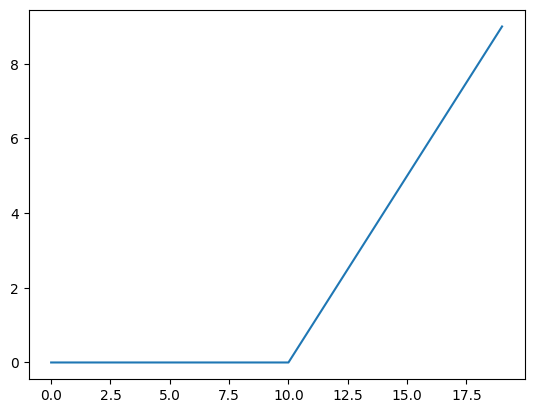

In [ ]:
plt.plot(torch.relu(A));

In [ ]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

In [ ]:
def relu(x: torch.tensor) -> torch.Tensor:
 return torch.maximum(torch.tensor(0), x) # inputs must be tensors
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

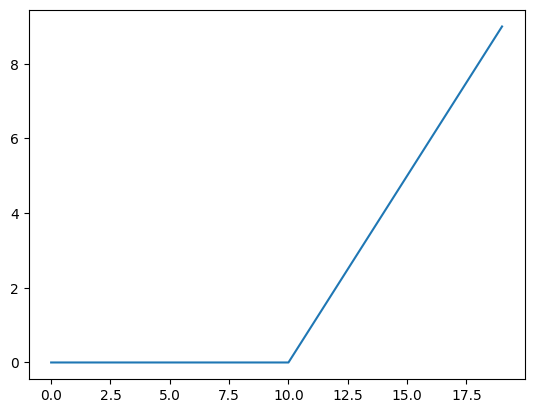

In [ ]:
# Plot ReLU activation function
plt.plot(relu(A));

In [ ]:
# Now let's do the same for sigmoid

def sigmoid(x):
  return 1/ (1 +torch.exp(-x))

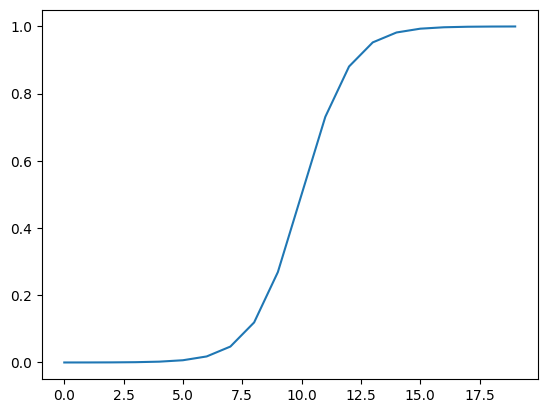

In [ ]:
plt.plot(torch.sigmoid(A));

# Putting it all together with a multi-class classification problem

* Binary classification = one thing or another (cat vs. dog, spam vs. not spam, fraud or not fraud)

* Multi-class classification = more than one thing or another (cat vs dog vs chicken)

### 8.1 Creating a toy multi-class dataset

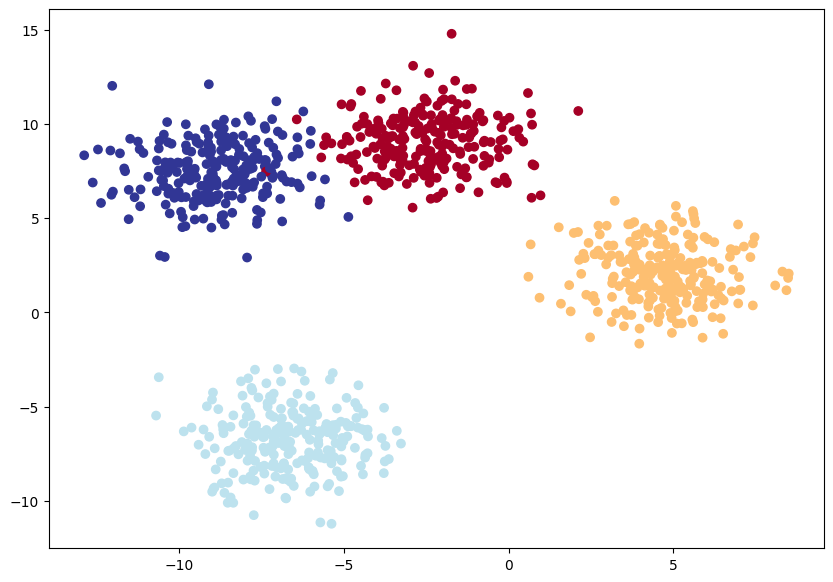

In [ ]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # Corrected from center_std to cluster_std
                            random_state=RANDOM_SEED)

# turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_blob,
                                                    y_blob,
                                                    test_size=0.2,
                                                    random_state=RANDOM_SEED)

# Plot data (visualize, visualize, visualize)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

# Building a multi-class classification model in PyTorch

In [ ]:
#  Create device agnostic code

device = "cuda" if torch.cuda.is_available () else 'cpu'
device

'cpu'

In [ ]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """Initializes multi-class classification model

    Args:
        input_features (int): Number of input features to the model
        output_features (int): Number of output features of the model
        hidden_units (int): Number of hidden units between layers, default 8
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
X_train.shape, y_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 2., 2., 0.]))

In [ ]:
torch.unique(y_train)

tensor([0., 1., 2., 3.])

### 8.3 Create a loss function and an optimizeer for a multi class classification model

In [ ]:
# Create aloss function for multi class calssifiaction - loss function measures how wrong out model's prections are
loss_fn = nn.CrossEntropyLoss()

# create an optimizer for multi-class classification - optimizer updates our model parameters to try and reduce the loss
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1) # learning rate is a hyperparameter you can change

### 8.4  Getting prediction probabilities  for a multi-class PyTorch model

In order to evaluate and train and test our model, we need to cnvert our model's outputs (logits) to prediction probabilities and then to prediction label

Logits (raw output of the model) -> pred probs ->   (use torch.softmax) -> Pred labels (take the argmax of the prediction probabilities)


In [ ]:
# let's get some raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
  y_preds = model_4(X_test.to(device))

y_preds[:10]

tensor([[-0.8294, -0.6839, -1.5804, -1.1695],
        [ 0.3150, -0.1745,  0.1625,  0.0236],
        [ 0.8404, -0.0173,  0.2878, -0.5044],
        [-0.5074, -0.3063, -0.9238, -0.7890],
        [-0.2101, -1.2519, -1.1801, -0.6229],
        [ 0.3260, -0.1498,  0.1967,  0.0374],
        [ 0.7363,  0.0102,  0.2043, -0.6082],
        [ 0.0698, -0.8390, -0.7259, -0.3541],
        [ 1.0233, -0.0437,  0.3895, -0.4317],
        [ 0.0304, -0.9426, -0.8531, -0.4033]])

In [ ]:
y_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.])

In [ ]:
# Convert our model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_preds, dim=1)
print("First 5 raw logits:")
print(y_preds[:5])
print("\nFirst 5 prediction probabilities:")
print(y_pred_probs[:5])

First 5 raw logits:
tensor([[-0.8294, -0.6839, -1.5804, -1.1695],
        [ 0.3150, -0.1745,  0.1625,  0.0236],
        [ 0.8404, -0.0173,  0.2878, -0.5044],
        [-0.5074, -0.3063, -0.9238, -0.7890],
        [-0.2101, -1.2519, -1.1801, -0.6229]])

First 5 prediction probabilities:
tensor([[0.2994, 0.3463, 0.1413, 0.2131],
        [0.3107, 0.1904, 0.2668, 0.2321],
        [0.4424, 0.1876, 0.2546, 0.1153],
        [0.2750, 0.3362, 0.1813, 0.2075],
        [0.4178, 0.1474, 0.1584, 0.2765]])


In [ ]:
torch.sum(y_pred_probs[0])

tensor(1.0000)

In [ ]:
# Convert our mode's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

In [ ]:
y_test

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

# 8.5 Creating a training loop and testing loop for a multi-class PyTorch model

In [ ]:
# Fit the multi-class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs = 100

# Put the data to the target device (using the correct variable names from our split)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop through data
for epoch in range(epochs):
  ### Training
  model_4.train()

  y_logits = model_4(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # Convert logits -> prediction probabilities -> prediction labels

  loss = loss_fn(y_logits, y_train.long()) # Ensure targets are the correct type for CrossEntropyLoss

  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test.long())
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc {acc:.2f}% | Test loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.1770, Acc 47.88% | Test loss: 1.0337 | Test acc: 70.00%
Epoch: 10 | Loss: 0.2945, Acc 99.25% | Test loss: 0.2736 | Test acc: 99.50%
Epoch: 20 | Loss: 0.1114, Acc 99.12% | Test loss: 0.1044 | Test acc: 99.50%
Epoch: 30 | Loss: 0.0692, Acc 99.00% | Test loss: 0.0633 | Test acc: 99.50%
Epoch: 40 | Loss: 0.0533, Acc 99.00% | Test loss: 0.0470 | Test acc: 99.50%
Epoch: 50 | Loss: 0.0452, Acc 99.00% | Test loss: 0.0384 | Test acc: 99.50%
Epoch: 60 | Loss: 0.0404, Acc 99.12% | Test loss: 0.0332 | Test acc: 99.50%
Epoch: 70 | Loss: 0.0372, Acc 99.12% | Test loss: 0.0297 | Test acc: 99.50%
Epoch: 80 | Loss: 0.0349, Acc 99.12% | Test loss: 0.0271 | Test acc: 99.50%
Epoch: 90 | Loss: 0.0333, Acc 99.12% | Test loss: 0.0252 | Test acc: 99.50%


 ### 8.6 Making and evaluating predictions with a PyTorch multi-class model

In [ ]:
# Make predictions with model_4
model_4.eval()
with torch.inference_mode():
  # Use the correct variable name 'X_test' on the target device
  y_logits = model_4(X_test.to(device))

# View the first 10 predictions (corrected 'y_logist' typo to 'y_logits')
y_logits[:10]

tensor([[-1.0978,  5.3479, -8.9898, -9.3877],
        [-2.5806, -5.6738, -4.2485,  2.9038],
        [-5.0535, -5.7551,  5.5950, -3.5053],
        [-1.7245,  4.4396, -5.1287, -5.6077],
        [ 3.3434, -1.9503, -9.5384, -7.3989],
        [-3.6211, -6.7591, -4.6235,  3.8124],
        [-4.0775, -4.4890,  5.8004, -4.1488],
        [ 3.0503, -4.8046, -7.2217, -3.6241],
        [-6.7765, -7.8835,  5.7806, -2.9854],
        [ 3.3868, -3.9232, -7.8002, -4.7398]])

In [ ]:
# Go from logits -> Prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[1.5848e-03, 9.9841e-01, 5.9229e-07, 3.9784e-07],
        [4.1300e-03, 1.8731e-04, 7.7909e-04, 9.9490e-01],
        [2.3733e-05, 1.1767e-05, 9.9985e-01, 1.1161e-04],
        [2.0989e-03, 9.9779e-01, 6.9758e-05, 4.3206e-05],
        [9.9498e-01, 4.9977e-03, 2.5310e-06, 2.1502e-05],
        [5.9066e-04, 2.5616e-05, 2.1677e-04, 9.9917e-01],
        [5.1290e-05, 3.3986e-05, 9.9987e-01, 4.7759e-05],
        [9.9832e-01, 3.8717e-04, 3.4528e-05, 1.2606e-03],
        [3.5192e-06, 1.1634e-06, 9.9984e-01, 1.5592e-04],
        [9.9902e-01, 6.6816e-04, 1.3840e-05, 2.9530e-04]])

In [ ]:
y_test

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

In [ ]:
# Go from pred probs to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

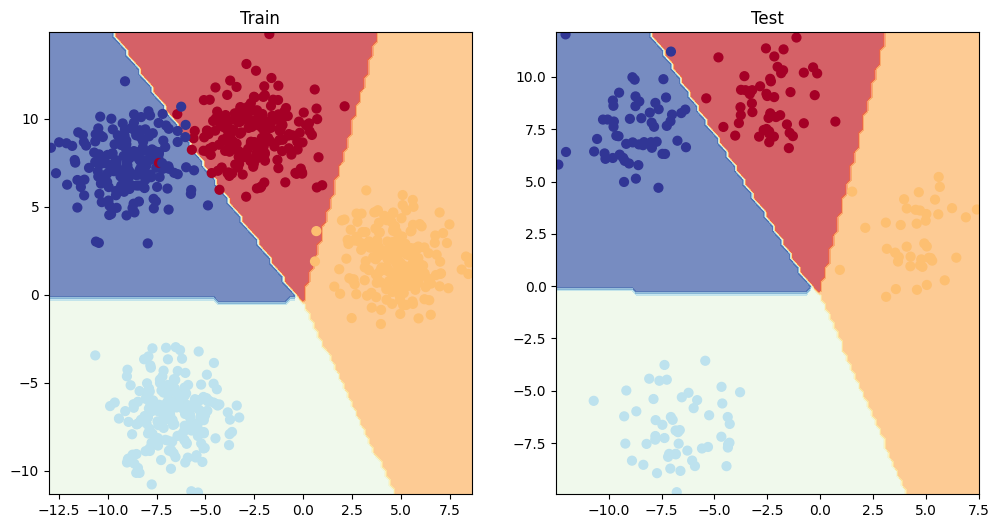

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_test, y_test)

### 9. A few more classification metrics.. (to evaluate classification models)

* Accuracy - out of 100 samples, how many does our model get right?
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report

If you want access to alot of Pytorch see torchmetrics.


In [ ]:
! pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 12.3 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

# Setup metric with task and number of classes
torchmetric_accuracy = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)

# Calculate accuracy (targets must be integers/LongTensor for multiclass metric evaluation)
torchmetric_accuracy(y_preds, y_test.long())

tensor(0.9950)





## Exercises & Extra-curriculum